# 🔍 Agrupamento de Clientes (Clustering)
## Dataset: *Default of Credit Card Clients*
---
**Disciplina:** Tópicos em Engenharia de Computação  
**Dataset:** Default of Credit Card Clients – UCI Machine Learning Repository  
**Objetivo:** Identificar grupos homogêneos de clientes por meio de técnicas de agrupamento não supervisionado (K-Means e Clusterização Hierárquica), revelando perfis de comportamento financeiro.

> **Fonte:** Yeh, I. C., & Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications.


---
## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


---
## 2. Carregamento e Reprodução do Pré-processamento
O dataset é carregado diretamente do UCI e submetido ao mesmo pipeline de tratamento desenvolvido anteriormente.


In [2]:
URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00350/default%20of%20credit%20card%20clients.xls"
)

df_raw = pd.read_excel(URL, header=1)
print(f"Dataset carregado: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} variáveis")


Dataset carregado: 30,000 registros × 25 variáveis


In [3]:
# ── Renomeação das colunas ────────────────────────────────────────────────
df = df_raw.copy()
mapa_colunas = {
    'ID': 'id', 'LIMIT_BAL': 'limite_credito',
    'SEX': 'sexo', 'EDUCATION': 'escolaridade', 'MARRIAGE': 'estado_civil',
    'AGE': 'idade',
    'PAY_0': 'status_pag_set', 'PAY_2': 'status_pag_ago',
    'PAY_3': 'status_pag_jul', 'PAY_4': 'status_pag_jun',
    'PAY_5': 'status_pag_mai', 'PAY_6': 'status_pag_abr',
    'BILL_AMT1': 'fatura_set', 'BILL_AMT2': 'fatura_ago',
    'BILL_AMT3': 'fatura_jul', 'BILL_AMT4': 'fatura_jun',
    'BILL_AMT5': 'fatura_mai', 'BILL_AMT6': 'fatura_abr',
    'PAY_AMT1': 'pagamento_set', 'PAY_AMT2': 'pagamento_ago',
    'PAY_AMT3': 'pagamento_jul', 'PAY_AMT4': 'pagamento_jun',
    'PAY_AMT5': 'pagamento_mai', 'PAY_AMT6': 'pagamento_abr',
    'default payment next month': 'inadimplente',
}
df.rename(columns=mapa_colunas, inplace=True)

# ── Limpeza ───────────────────────────────────────────────────────────────
df.drop(columns=['id'], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Mapeamento categórico ─────────────────────────────────────────────────
df['sexo']         = df['sexo'].map({1: 'Masculino', 2: 'Feminino'})
df['escolaridade'] = df['escolaridade'].map(
    {0:'Outros', 1:'Pós-graduação', 2:'Graduação', 3:'Ensino Médio',
     4:'Outros', 5:'Outros', 6:'Outros'})
df['estado_civil'] = df['estado_civil'].map(
    {0:'Outros', 1:'Casado', 2:'Solteiro', 3:'Outros'})
df['inadimplente'] = df['inadimplente'].astype(int)

# ── Feature engineering ──────────────────────────────────────────────────
cols_fatura    = ['fatura_set','fatura_ago','fatura_jul','fatura_jun','fatura_mai','fatura_abr']
cols_pagamento = ['pagamento_set','pagamento_ago','pagamento_jul','pagamento_jun','pagamento_mai','pagamento_abr']
cols_status    = ['status_pag_set','status_pag_ago','status_pag_jul','status_pag_jun','status_pag_mai','status_pag_abr']

df['media_fatura']    = df[cols_fatura].mean(axis=1).round(2)
df['media_pagamento'] = df[cols_pagamento].mean(axis=1).round(2)
df['taxa_utilizacao'] = np.clip(
    np.where(df['limite_credito'] > 0, df['media_fatura'] / df['limite_credito'], 0), 0, 1.0
).round(4)
df['qtd_atrasos'] = (df[cols_status] >= 1).sum(axis=1)

bins, labels = [0,25,35,45,55,100], ['Até 25','26–35','36–45','46–55','Acima de 55']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

def classificar_risco(row):
    if row['taxa_utilizacao'] >= 0.8 or row['qtd_atrasos'] >= 3:
        return 'Alto'
    elif row['taxa_utilizacao'] >= 0.5 or row['qtd_atrasos'] >= 1:
        return 'Médio'
    return 'Baixo'
df['perfil_risco'] = df.apply(classificar_risco, axis=1)

print(f"Pré-processamento concluído!  Shape: {df.shape}")
print(df.head(3).to_string())


Pré-processamento concluído!  Shape: (29965, 30)
   limite_credito      sexo escolaridade estado_civil  idade  status_pag_set  status_pag_ago  status_pag_jul  status_pag_jun  status_pag_mai  status_pag_abr  fatura_set  fatura_ago  fatura_jul  fatura_jun  fatura_mai  fatura_abr  pagamento_set  pagamento_ago  pagamento_jul  pagamento_jun  pagamento_mai  pagamento_abr  inadimplente  media_fatura  media_pagamento  taxa_utilizacao  qtd_atrasos faixa_etaria perfil_risco
0           20000  Feminino    Graduação       Casado     24               2               2              -1              -1              -2              -2        3913        3102         689           0           0           0              0            689              0              0              0              0             1     1284.0000         114.8300           0.0642            2       Até 25        Médio
1          120000  Feminino    Graduação     Solteiro     26              -1               2               0   

---
## 3. Seleção e Normalização das Variáveis para Clustering
Utilizam-se apenas as variáveis numéricas financeiramente relevantes.  
A padronização (Z-score via `StandardScaler`) é obrigatória para que nenhuma variável domine a métrica de distância.


In [4]:
# Variáveis selecionadas para o agrupamento
features = [
    'limite_credito',
    'idade',
    'media_fatura',
    'media_pagamento',
    'taxa_utilizacao',
    'qtd_atrasos',
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Variáveis selecionadas para clustering:")
for f in features:
    print(f"   • {f}")
print(f"\nShape da matriz normalizada: {X_scaled.shape}")
print("\nEstatísticas após padronização:")
display(X_scaled_df.describe().round(4))


Variáveis selecionadas para clustering:
   • limite_credito
   • idade
   • media_fatura
   • media_pagamento
   • taxa_utilizacao
   • qtd_atrasos

Shape da matriz normalizada: (29965, 6)

Estatísticas após padronização:


,limite_credito,idade,media_fatura,media_pagamento,taxa_utilizacao,qtd_atrasos
count,29965.0000,29965.0000,29965.0000,29965.0000,29965.0000,29965.0000
mean,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.2134,-1.5715,-1.5973,-0.5207,-1.0801,-0.5366
25%,-0.9051,-0.8122,-0.6351,-0.4106,-0.9918,-0.5366
50%,-0.2115,-0.1614,-0.3780,-0.2841,-0.2480,-0.5366
75%,0.5592,0.5979,0.1918,0.0314,0.9260,0.1066
max,6.4162,4.7197,13.1528,61.3345,1.8336,3.3224


---
## 4. Determinação do Número Ideal de Clusters
### 4.1 Método do Cotovelo (*Elbow Method*)
Avalia a inércia (soma das distâncias quadráticas intra-cluster) para cada valor de *k*.


In [5]:
K_RANGE = range(2, 11)
inercias = []
silhuetas = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels_k))

print("k | Inércia        | Silhueta")
print("-" * 40)
for k, in_, sil in zip(K_RANGE, inercias, silhuetas):
    print(f"{k:2d} | {in_:>14,.1f} | {sil:.4f}")


k | Inércia        | Silhueta
----------------------------------------
 2 |      141,820.3 | 0.2551
 3 |      116,000.2 | 0.2686
 4 |       98,318.5 | 0.2729
 5 |       87,647.0 | 0.2304
 6 |       77,278.8 | 0.2698
 7 |       68,299.0 | 0.2584
 8 |       63,466.6 | 0.2579
 9 |       58,855.2 | 0.2593
10 |       55,103.4 | 0.2605


### 📈 Gráfico 4.1 — Cotovelo e Coeficiente de Silhueta

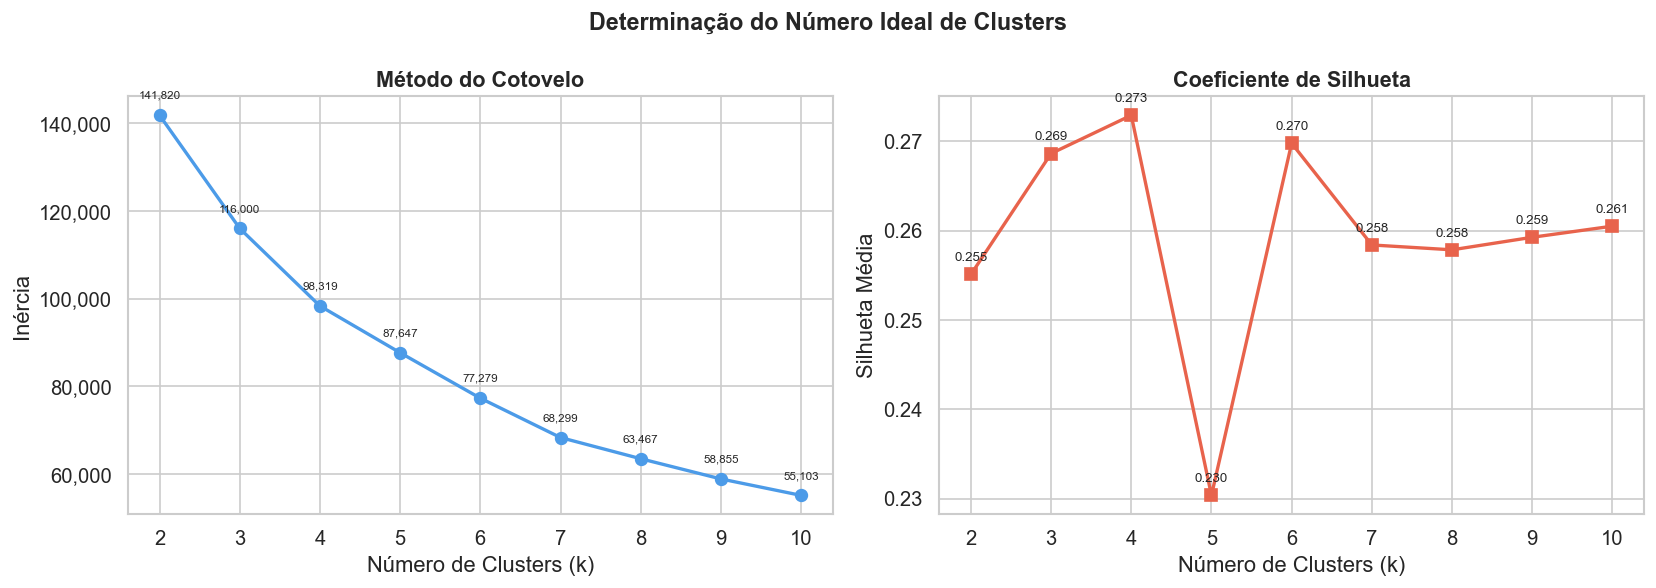

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ks = list(K_RANGE)

# Cotovelo
axes[0].plot(ks, inercias, 'o-', color='#4C9BE8', linewidth=2, markersize=7)
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for x, y in zip(ks, inercias):
    axes[0].annotate(f'{y:,.0f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=7)

# Silhueta
axes[1].plot(ks, silhuetas, 's-', color='#E8634C', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhueta Média')
for x, y in zip(ks, silhuetas):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Determinação do Número Ideal de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5. K-Means com k Ótimo
Treinamento do modelo K-Means com o número de clusters escolhido a partir da análise anterior.


In [7]:
K_OTIMO = 4   # ajuste conforme o cotovelo/silhueta observados

km_final = KMeans(n_clusters=K_OTIMO, init='k-means++', n_init=20, random_state=42)
df['cluster_kmeans'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster_kmeans'])
print(f"K-Means treinado com k={K_OTIMO}")
print(f"Inércia final    : {km_final.inertia_:,.2f}")
print(f"Silhueta média   : {sil_final:.4f}")
print("\nDistribuição dos clusters:")
display(df['cluster_kmeans'].value_counts().sort_index().rename('Clientes'))


K-Means treinado com k=4
Inércia final    : 98,318.42
Silhueta média   : 0.2731

Distribuição dos clusters:


cluster_kmeans
0     9516
1    14043
2     2979
3     3427
Name: Clientes, dtype: int64

---
## 6. Análise do Coeficiente de Silhueta por Amostra
### 📈 Gráfico 6.1 — Silhouette Plot
Visualiza a qualidade da separação de cada ponto dentro do seu cluster.


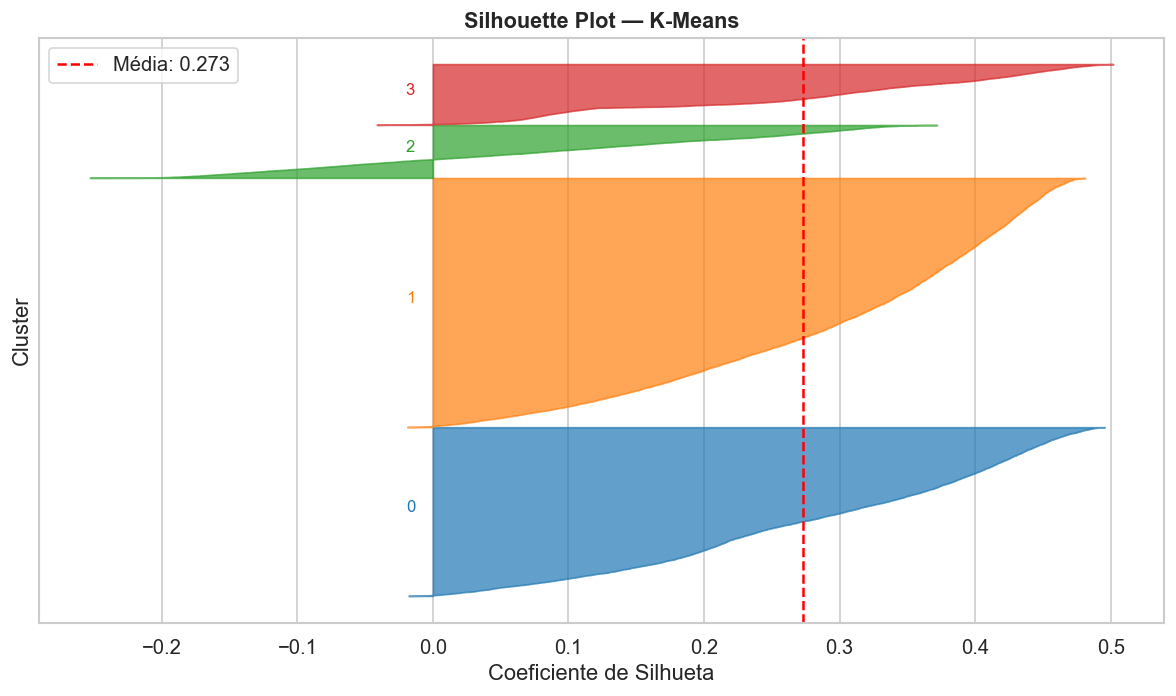


Silhueta média geral: 0.2731  (valores próximos de 1 indicam boa separação)


In [8]:
sil_samples = silhouette_samples(X_scaled, df['cluster_kmeans'])
cores = sns.color_palette('tab10', K_OTIMO)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(K_OTIMO):
    ith_sil = np.sort(sil_samples[df['cluster_kmeans'] == i])
    size_cluster_i = ith_sil.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=cores[i], edgecolor=cores[i], alpha=0.7)
    ax.text(-0.02, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10, color=cores[i])
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {sil_final:.3f}')
ax.set_title('Silhouette Plot — K-Means')
ax.set_xlabel('Coeficiente de Silhueta')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nSilhueta média geral: {sil_final:.4f}  (valores próximos de 1 indicam boa separação)")


---
## 7. Visualização dos Clusters via PCA (2D)
Redução de dimensionalidade com PCA para projetar os clusters em duas componentes principais.

### 📈 Gráfico 7.1 — Projeção PCA dos Clusters


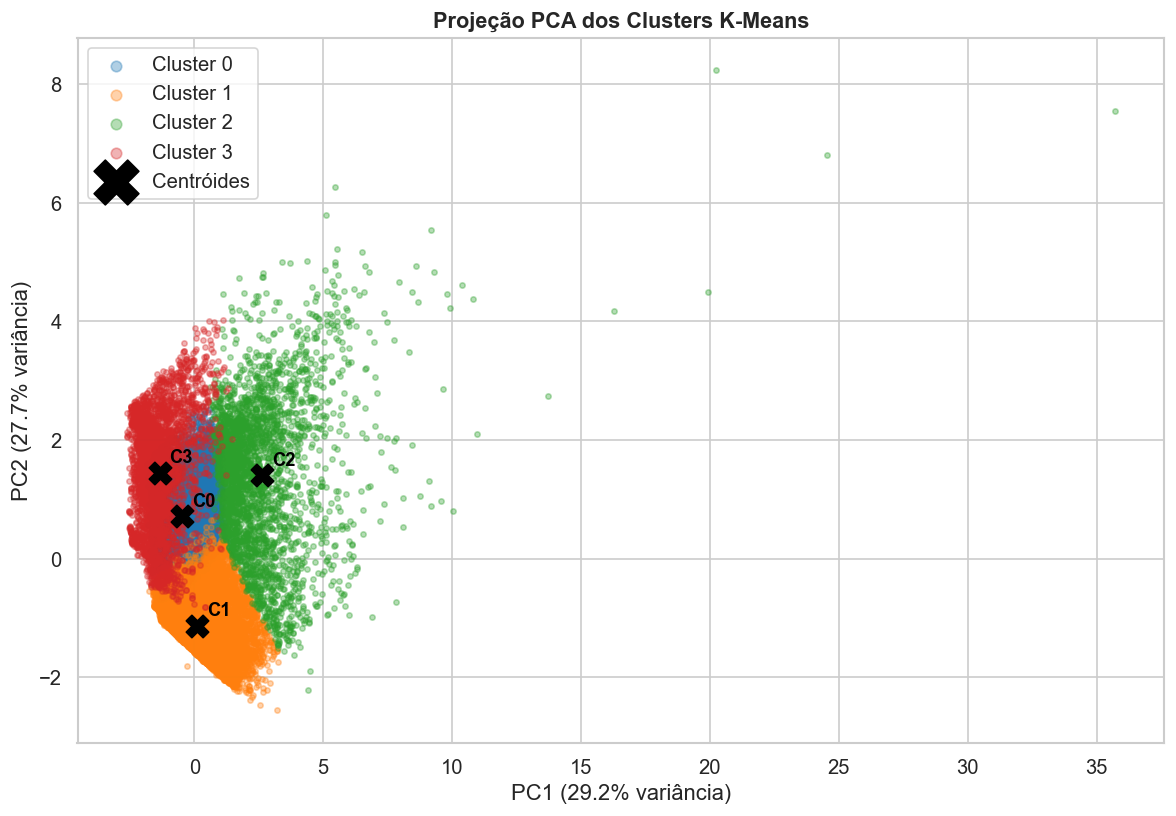

Variância explicada pelas 2 componentes: 57.0%


In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variancia = pca.explained_variance_ratio_

df_pca = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
                        'Cluster': df['cluster_kmeans'].astype(str)})

fig, ax = plt.subplots(figsize=(10, 7))
for i, grp in df_pca.groupby('Cluster'):
    ax.scatter(grp['PC1'], grp['PC2'], label=f'Cluster {i}',
               alpha=0.35, s=10, color=cores[int(i)])

# Centróides projetados
centroides_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='black', marker='X', s=180, zorder=5, label='Centróides')
for i, (cx, cy) in enumerate(centroides_pca):
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold',
                xytext=(6, 6), textcoords='offset points', color='black')

ax.set_title('Projeção PCA dos Clusters K-Means')
ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

print(f"Variância explicada pelas 2 componentes: {sum(variancia)*100:.1f}%")


---
## 8. Clusterização Hierárquica (Agglomerative)
Método alternativo que constrói a hierarquia de agrupamentos de forma *bottom-up*.
### 8.1 Dendrograma (Amostra de 1 000 Registros)


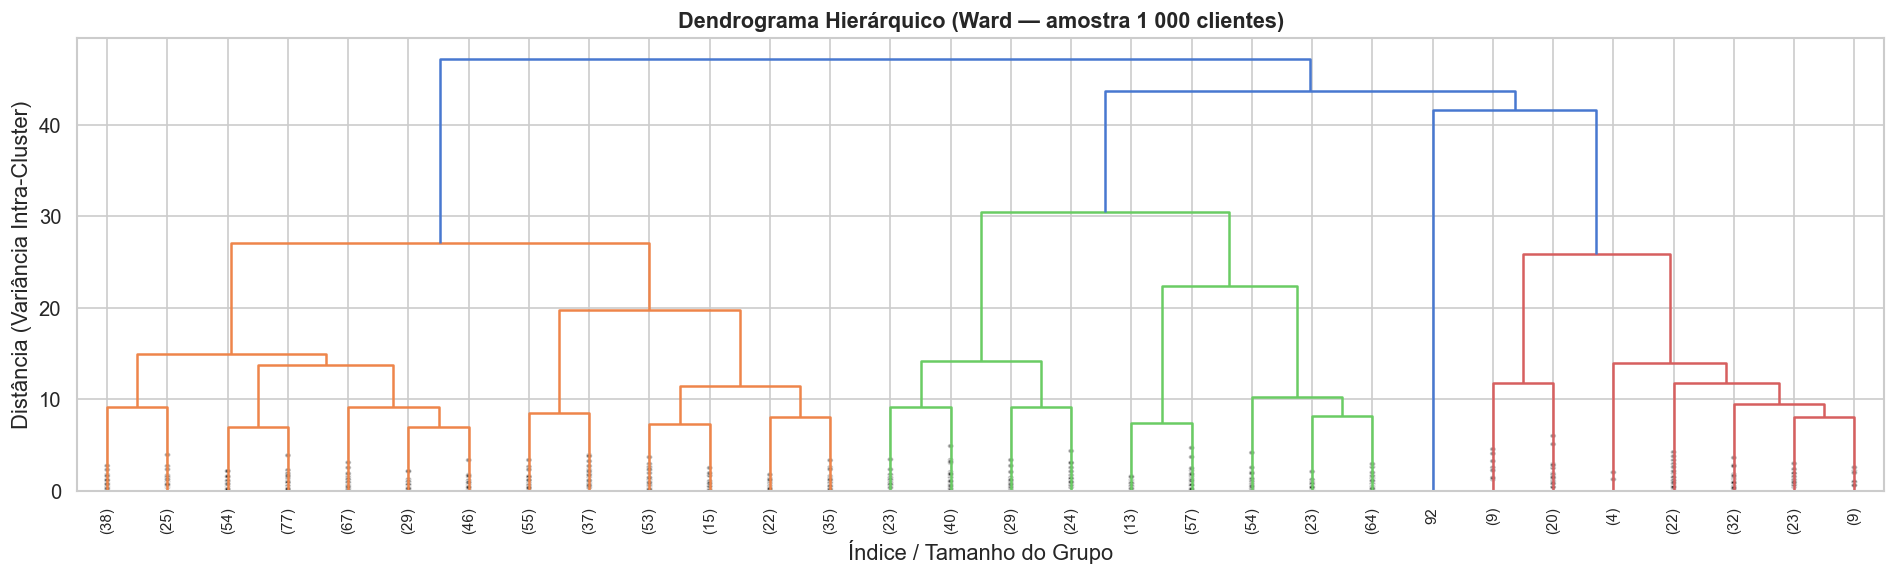

In [10]:
# Amostra para viabilizar o dendrograma
np.random.seed(42)
idx_amostra = np.random.choice(len(X_scaled), size=1000, replace=False)
X_amostra   = X_scaled[idx_amostra]

Z = linkage(X_amostra, method='ward')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Dendrograma Hierárquico (Ward — amostra 1 000 clientes)')
ax.set_xlabel('Índice / Tamanho do Grupo')
ax.set_ylabel('Distância (Variância Intra-Cluster)')
plt.tight_layout()
plt.show()


### 8.2 Treinamento do Agglomerative Clustering

In [11]:
agg = AgglomerativeClustering(n_clusters=K_OTIMO, linkage='ward')
df['cluster_hierarquico'] = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, df['cluster_hierarquico'])
print(f"Agglomerative Clustering — k={K_OTIMO}")
print(f"Silhueta média: {sil_agg:.4f}")
print("\nDistribuição:")
display(df['cluster_hierarquico'].value_counts().sort_index().rename('Clientes'))


Agglomerative Clustering — k=4
Silhueta média: 0.2294

Distribuição:


cluster_hierarquico
0     4907
1    15123
2     6874
3     3061
Name: Clientes, dtype: int64

---
## 9. Comparação K-Means × Clusterização Hierárquica
### 📈 Gráfico 9.1 — Projeção PCA lado a lado


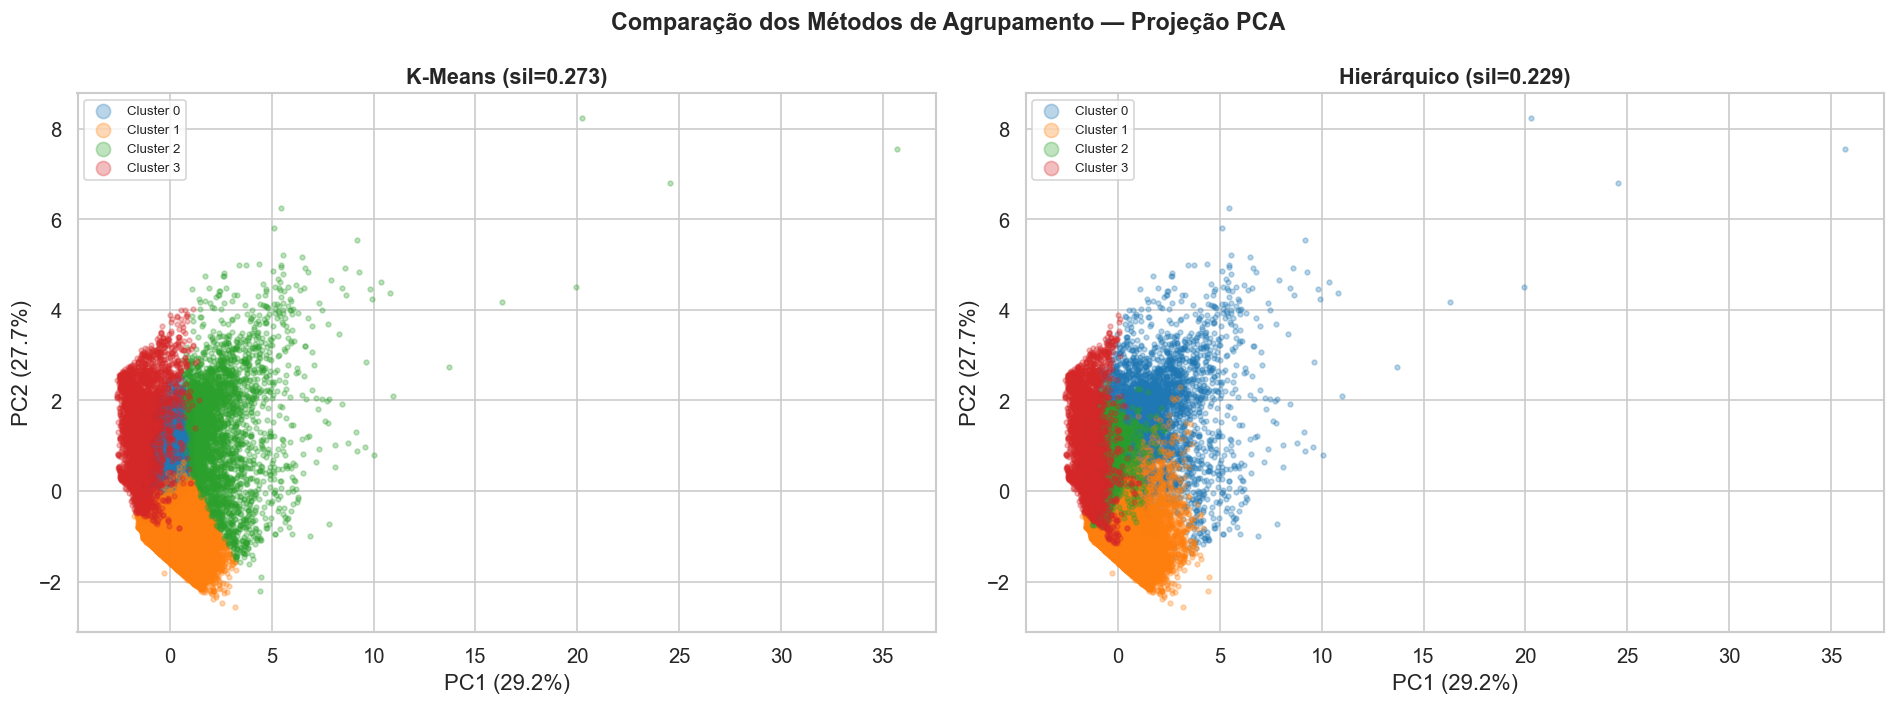

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, titulo, sil in zip(
        axes,
        ['cluster_kmeans', 'cluster_hierarquico'],
        [f'K-Means (sil={silhouette_score(X_scaled, df["cluster_kmeans"]):.3f})',
         f'Hierárquico (sil={silhouette_score(X_scaled, df["cluster_hierarquico"]):.3f})'],
        [sil_final, sil_agg]):

    for i in sorted(df[col].unique()):
        mask = df[col] == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'Cluster {i}', alpha=0.3, s=8, color=cores[i])
    ax.set_title(titulo)
    ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
    ax.legend(markerscale=3, fontsize=8)

plt.suptitle('Comparação dos Métodos de Agrupamento — Projeção PCA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10. Perfil dos Clusters (K-Means)
Análise das médias das variáveis originais por cluster para interpretar os perfis encontrados.


In [13]:
perfil_num = (
    df.groupby('cluster_kmeans')[features + ['inadimplente']]
      .mean()
      .round(4)
)
perfil_num.index.name = 'Cluster'
print("Médias das variáveis por cluster:")
display(perfil_num)


Médias das variáveis por cluster:


,limite_credito,idade,media_fatura,media_pagamento,taxa_utilizacao,qtd_atrasos,inadimplente
Cluster,,,,,,,
0,75819.8823,34.2739,49140.9168,3315.8179,0.6593,0.3863,0.1974
1,217720.5725,36.0119,13046.0434,4234.5422,0.0664,0.3272,0.1580
2,323557.4622,37.6066,183062.7166,20033.6606,0.6084,0.3353,0.1474
3,80119.6382,34.8707,44683.2307,2204.4938,0.6097,4.5897,0.6110


### 📈 Gráfico 10.1 — Heatmap dos Perfis (valores padronizados)

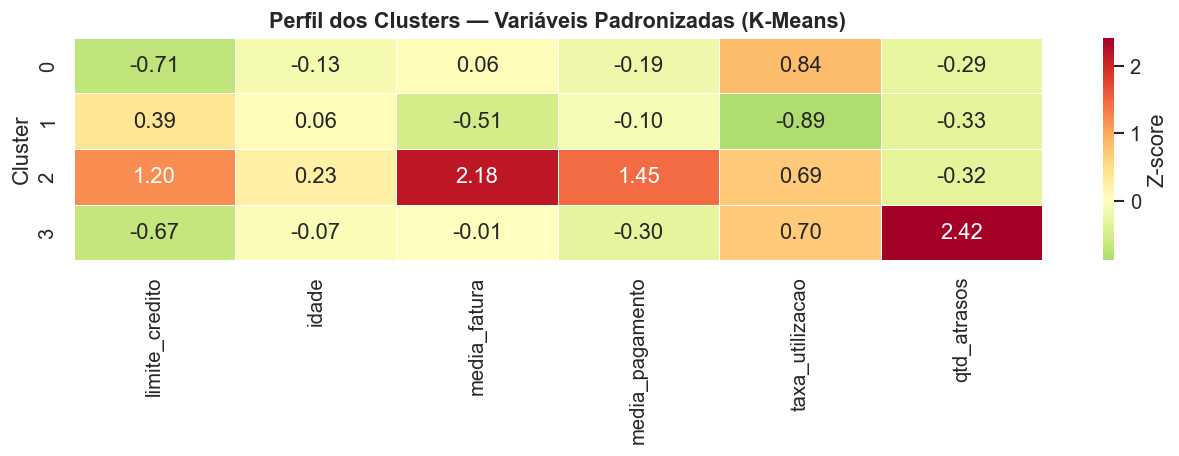

In [14]:
perfil_scaled = pd.DataFrame(
    scaler.transform(perfil_num[features]),
    index=perfil_num.index,
    columns=features
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(perfil_scaled, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Perfil dos Clusters — Variáveis Padronizadas (K-Means)')
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()


### 📈 Gráfico 10.2 — Taxa de Inadimplência por Cluster

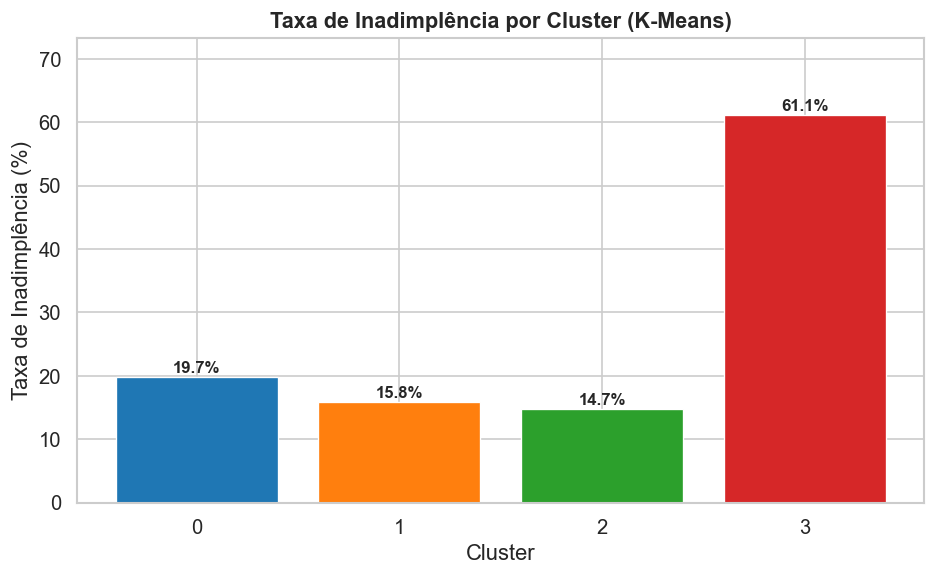

In [15]:
taxa_cluster = (
    df.groupby('cluster_kmeans')['inadimplente']
      .mean()
      .reset_index()
      .rename(columns={'inadimplente': 'taxa_inadimplencia'})
)
taxa_cluster['taxa_pct'] = (taxa_cluster['taxa_inadimplencia'] * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    taxa_cluster['cluster_kmeans'].astype(str),
    taxa_cluster['taxa_pct'],
    color=[cores[i] for i in taxa_cluster['cluster_kmeans']],
    edgecolor='white', linewidth=0.8
)
for bar, (_, row) in zip(bars, taxa_cluster.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{row['taxa_pct']:.1f}%",
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Taxa de Inadimplência por Cluster (K-Means)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Taxa de Inadimplência (%)')
ax.set_ylim(0, taxa_cluster['taxa_pct'].max() * 1.2)
plt.tight_layout()
plt.show()


---
## 11. Distribuição Categórica por Cluster
Composição de cada cluster quanto a sexo, escolaridade, estado civil e perfil de risco.

### 📈 Gráfico 11.1 — Variáveis Categóricas por Cluster


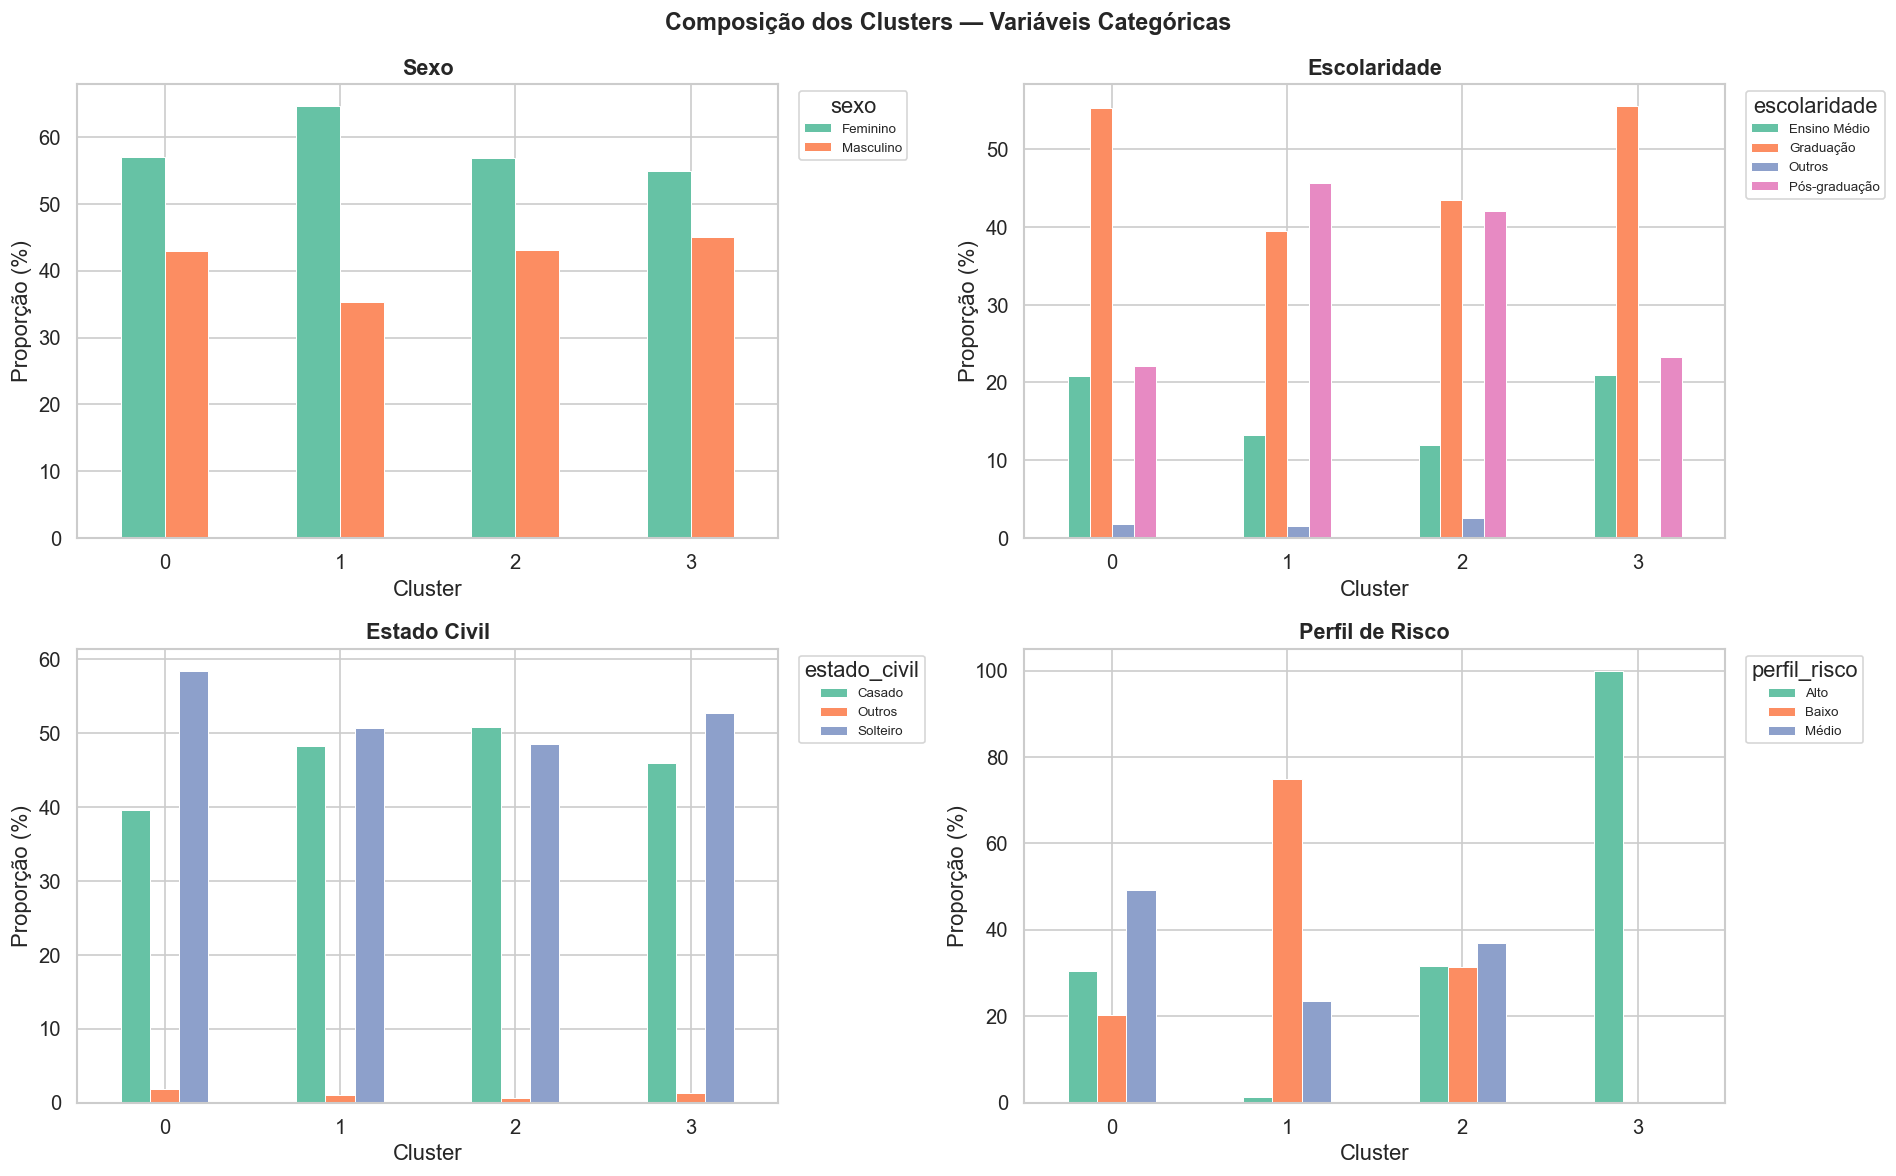

In [16]:
cats_plot = [
    ('sexo',         'Sexo'),
    ('escolaridade', 'Escolaridade'),
    ('estado_civil', 'Estado Civil'),
    ('perfil_risco', 'Perfil de Risco'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (col, titulo) in zip(axes.flat, cats_plot):
    tbl = (df.groupby(['cluster_kmeans', col])
             .size()
             .reset_index(name='n'))
    tbl['pct'] = tbl.groupby('cluster_kmeans')['n'].transform(lambda x: x / x.sum() * 100)

    pivot = tbl.pivot(index='cluster_kmeans', columns=col, values='pct').fillna(0)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.6,
               color=sns.color_palette('Set2', len(pivot.columns)))
    ax.set_title(titulo)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Proporção (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title=col, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Composição dos Clusters — Variáveis Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 12. Radar Chart — Perfil dos Clusters
Visualização radial que permite comparar o perfil médio de cada cluster em todas as dimensões simultaneamente.

### 📈 Gráfico 12.1 — Radar Chart


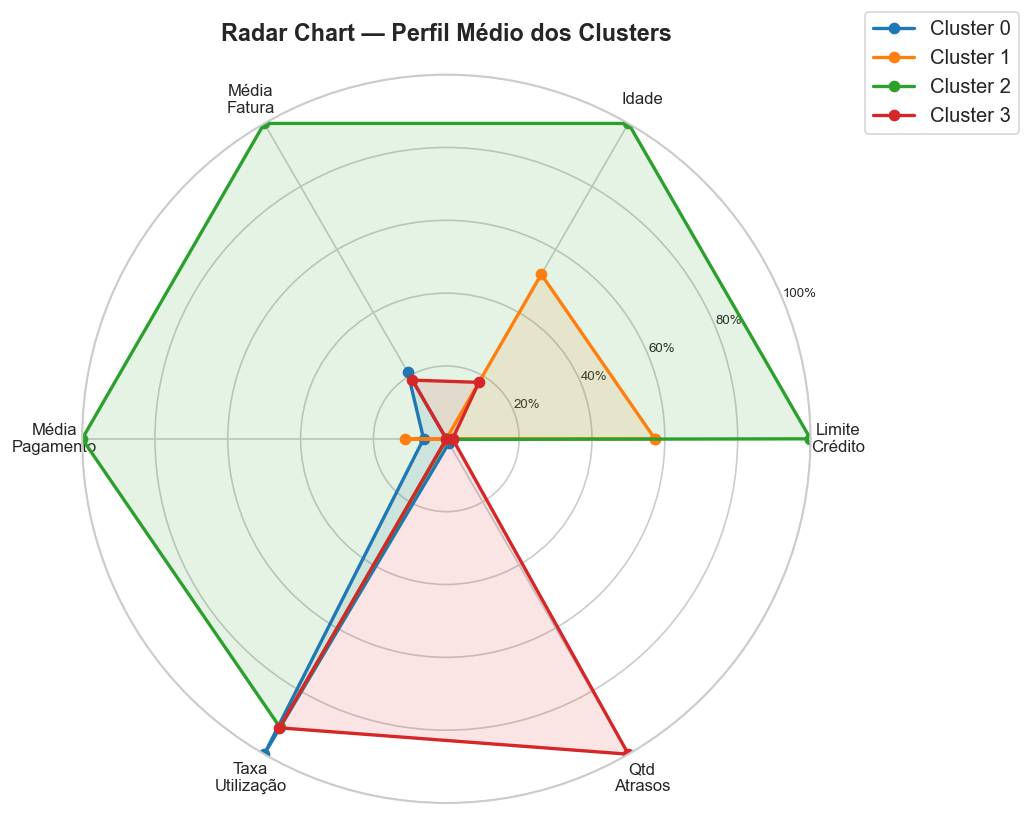

In [17]:
from matplotlib.patches import FancyArrowPatch

# Normaliza perfil para [0,1] para o radar
perfil_norm = (perfil_num[features] - perfil_num[features].min()) /               (perfil_num[features].max() - perfil_num[features].min())

labels_radar = [
    'Limite\nCrédito', 'Idade', 'Média\nFatura',
    'Média\nPagamento', 'Taxa\nUtilização', 'Qtd\nAtrasos'
]
N = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, row in perfil_norm.iterrows():
    valores = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, valores, '-o', linewidth=2, color=cores[i], label=f'Cluster {i}')
    ax.fill(angles, valores, alpha=0.12, color=cores[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], size=8)
ax.set_title('Radar Chart — Perfil Médio dos Clusters', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


---
## 13. Interpretação dos Clusters e Relatório Final


In [18]:
# ── Relatório quantitativo por cluster ───────────────────────────────────
print("=" * 70)
print("              RELATÓRIO DE AGRUPAMENTO — K-MEANS")
print("=" * 70)
print(f"  Método          : K-Means (k-means++, 20 inicializações)")
print(f"  Clusters (k)    : {K_OTIMO}")
print(f"  Inércia         : {km_final.inertia_:,.2f}")
print(f"  Silhueta média  : {sil_final:.4f}")
print("=" * 70)

resumo = df.groupby('cluster_kmeans').agg(
    Clientes=('inadimplente', 'count'),
    Taxa_Inad=('inadimplente', lambda x: f"{x.mean()*100:.1f}%"),
    Limite_Med=('limite_credito', lambda x: f"NT$ {x.mean():,.0f}"),
    Fatura_Med=('media_fatura', lambda x: f"NT$ {x.mean():,.0f}"),
    Pagto_Med=('media_pagamento', lambda x: f"NT$ {x.mean():,.0f}"),
    Util_Med=('taxa_utilizacao', lambda x: f"{x.mean()*100:.1f}%"),
    Atrasos_Med=('qtd_atrasos', lambda x: f"{x.mean():.2f}"),
)
display(resumo)

print("\n─── Silhueta por método ───────────────────────────────────")
print(f"  K-Means             : {sil_final:.4f}")
print(f"  Hierárquico (Ward)  : {sil_agg:.4f}")
print("─────────────────────────────────────────────────────────────")


              RELATÓRIO DE AGRUPAMENTO — K-MEANS
  Método          : K-Means (k-means++, 20 inicializações)
  Clusters (k)    : 4
  Inércia         : 98,318.42
  Silhueta média  : 0.2731


,Clientes,Taxa_Inad,Limite_Med,Fatura_Med,Pagto_Med,Util_Med,Atrasos_Med
cluster_kmeans,,,,,,,
0,9516,19.7%,"NT$ 75,820","NT$ 49,141","NT$ 3,316",65.9%,0.39
1,14043,15.8%,"NT$ 217,721","NT$ 13,046","NT$ 4,235",6.6%,0.33
2,2979,14.7%,"NT$ 323,557","NT$ 183,063","NT$ 20,034",60.8%,0.34
3,3427,61.1%,"NT$ 80,120","NT$ 44,683","NT$ 2,204",61.0%,4.59



─── Silhueta por método ───────────────────────────────────
  K-Means             : 0.2731
  Hierárquico (Ward)  : 0.2294
─────────────────────────────────────────────────────────────


---
## 14. Exportação do Dataset com Labels de Cluster


In [19]:
import os
os.makedirs('data', exist_ok=True)

SAIDA = 'data/credit_card_default_clustered.csv'
df.to_csv(SAIDA, index=False, encoding='utf-8-sig')
print(f"Dataset exportado: {SAIDA}")
print(f"Shape: {df.shape}  |  Colunas novas: 'cluster_kmeans', 'cluster_hierarquico'")


Dataset exportado: data/credit_card_default_clustered.csv
Shape: (29965, 32)  |  Colunas novas: 'cluster_kmeans', 'cluster_hierarquico'
